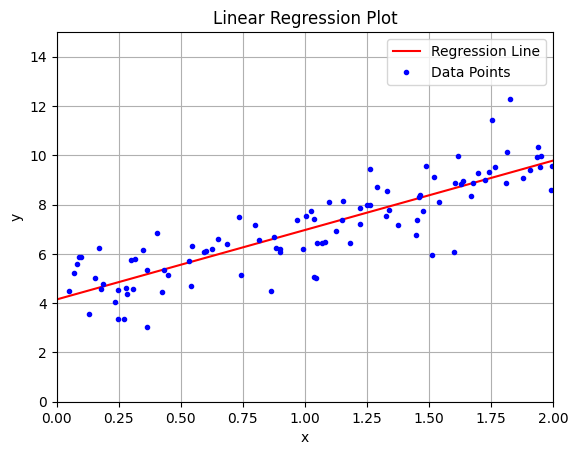

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X] # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

plt.plot(X_new, y_predict, "r-", label='Regression Line')
plt.plot(X, y, "b.", label='Data Points')
plt.axis([0, 2, 0, 15])
plt.title('Linear Regression Plot')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


[[1.45371231]
 [1.01042347]]


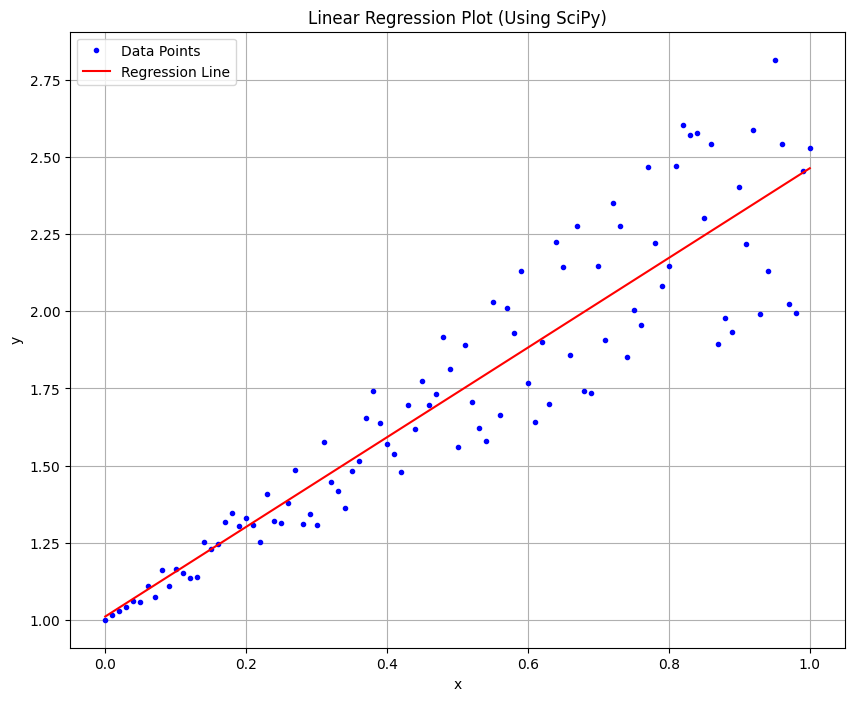

In [4]:
# Regression Line (using SciPy)

import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

# generate x and y
x = np.linspace(0, 1, 101)
y = 1 + x + x * np.random.random(len(x))

# assemble matrix A
A = np.vstack([x, np.ones(len(x))]).T

# turn y into a column vector
y = y[:, np.newaxis]

# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T,A)),A.T)),y)
print(alpha)

# plot the results
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.', label='Data Points')
plt.plot(x, alpha[0]*x + alpha[1], 'r', label='Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Plot (Using SciPy)')
plt.grid(True)
plt.legend()
plt.show()

Simple LR Coefficients: [1.00153184 1.52139715]
R² Score: 0.88


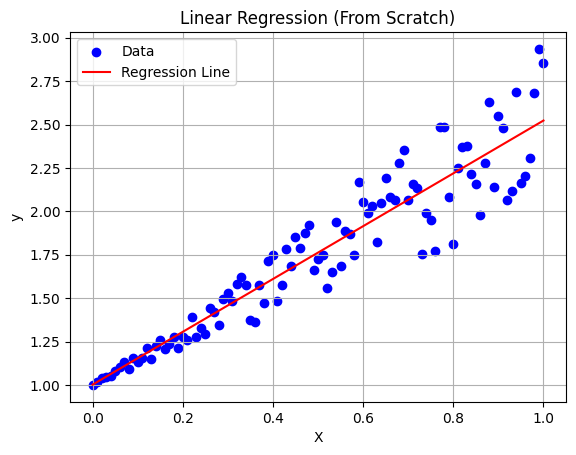

In [9]:
# Linear Regression (From Scratch)

class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  
   
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

# generate x and y
X_simple = np.linspace(0, 1, 101)
y_simple = 1 + x + x * np.random.random(len(x))

slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)


print(f"Simple LR Coefficients: {slr.coefficients_}")
print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(X_simple, y_simple, color='blue', label='Data')
plt.plot(X_simple, slr.y_pred_, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.title('Linear Regression (From Scratch)')
plt.grid(True)
plt.legend()
plt.show()